# Machine Learning #03 — Convolutional Neural Networks in PyTorch 🖼️

In the previous lesson we built a small **fully connected** network and wrote the
**training loop** ourselves. Today we keep *everything* we learned — tensors, the
`nn.Module` class, the loss/optimizer/loop — and change **only one thing**: instead
of `nn.Linear` layers we use **convolutional** layers `nn.Conv2d`.

That single change is what makes a network good at **images**.

> **The plan for today:**
> **understand convolution → build a CNN → train it → evaluate → look inside it 🔬**


## Why not just a plain neural network? 🤔

A 28×28 grayscale image has **784 pixels**. A colour 32×32 image has **3072**.
If we flatten the image and feed it to `nn.Linear`, two things go wrong:

- **Too many weights.** The first layer alone would need hundreds of thousands of
  parameters — slow to train and easy to overfit.
- **We throw away the geometry.** Flattening destroys the fact that neighbouring
  pixels belong together. An eye is an eye whether it is top-left or centre.

A **Convolutional Neural Network (CNN)** fixes both. It slides a **small filter**
over the image, reuses the *same* few weights everywhere, and keeps the 2-D
structure intact.

| | Fully connected (Lesson 2) | Convolutional (today) |
|---|---|---|
| Input | a flat vector of features | a 2-D image (with channels) |
| Core layer | `nn.Linear` | **`nn.Conv2d`** |
| Weights | one weight per input | a **small shared filter** |
| Keeps geometry? | ❌ no | ✅ yes |

## Imports and setup ⚙️
Remember to set a **GPU** runtime in Colab (*Runtime → Change runtime type → GPU*)!

In [1]:
!pip install torchinfo -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

import torchinfo

from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.11.0+cu128
device: cuda


# 📌 Part 1 — Understanding convolution

## 📒 Convolution

A **convolution** slides a small matrix — a **kernel** (also called a *filter* or
*mask*) — over the image. At every position it multiplies the kernel with the
pixels underneath and sums the result into a single output pixel.

In image processing it is defined as:

$$g(x, y) = \omega * f(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b}\omega(s,t)\,f(x-s, y-t)$$

where $f(x,y)$ is the original image, $\omega$ is the kernel, and $g(x,y)$ is the
filtered image.

![Example of the Convolution](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/convolution_example.gif?raw=true "Conv eg")

### 💡 Example filters

Different kernels extract different things. Notice these are **hand-designed** —
later the network will **learn** its own filters automatically. 🎯

|Name|Definition|
|----|:--------:|
|Identity| $\left[\begin{matrix}0&0&0\\0&1&0\\0&0&0\end{matrix}\right]$|
|Sobel vertical edges| $\left[\begin{matrix}+1&0&-1\\+2&0&-2\\+1&0&-1\end{matrix}\right]$|
|Sobel horizontal edges| $\left[\begin{matrix}+1&+2&+1\\0&0&0\\-1&-2&-1\end{matrix}\right]$|
|Edge detection| $\left[\begin{matrix}-1&-1&-1\\-1&8&-1\\-1&-1&-1\end{matrix}\right]$|
|Sharpen| $\left[\begin{matrix}0&-1&0\\-1&5&-1\\0&-1&0\end{matrix}\right]$|
|Uniform blur|$\frac{1}{9}\left[\begin{matrix}1&1&1\\1&1&1\\1&1&1\end{matrix}\right]$|
|Gaussian blur 3×3| $\frac{1}{16}\left[\begin{matrix}1&2&1\\2&4&2\\1&2&1\end{matrix}\right]$|

## 🚀 Let's apply filters ourselves — no network yet

Before we let a network learn filters, let's **be the filter** and apply a few by
hand. We use a classic grayscale test image (*"cameraman"*, bundled with
`scikit-image`) and the plain `scipy.signal.convolve2d` function.

image shape: (512, 512)


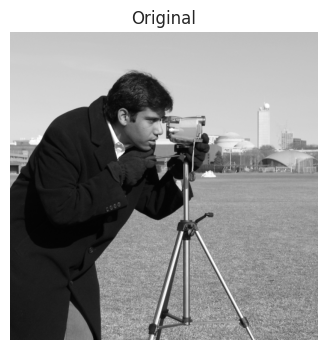

In [3]:
from skimage import data                 # bundled sample images, no download
from scipy.signal import convolve2d

img = data.camera()                        # 512x512 grayscale "cameraman" image
img = img / 255.0                          # normalise pixels to the 0-1 range
print("image shape:", img.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

In [4]:
# Define a few 3x3 kernels by hand
blur_mask = np.ones((3, 3)) / 9.0          # uniform blur (average of neighbours)

edge_mask = np.ones((3, 3)) * -1
edge_mask[1, 1] = 8                        # edge detection (centre 8, neighbours -1)

sharpen_mask = np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]])    # sharpen

print("edge kernel:\n", edge_mask)

edge kernel:
 [[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


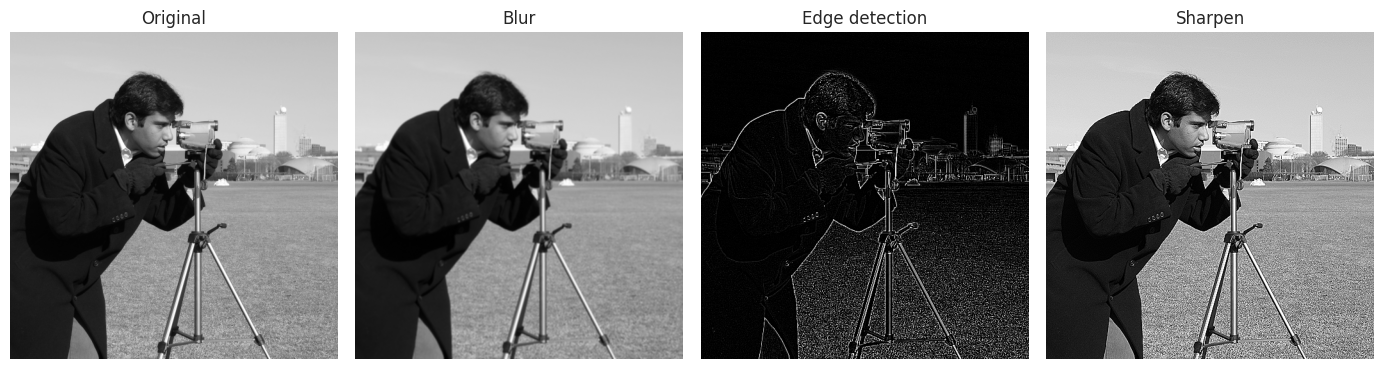

In [5]:
# convolve2d slides the kernel across the whole image.
#   boundary='symm' -> mirror the image at the borders (so the filter has values to read)
#   mode='same'     -> output keeps the same size as the input
img_blur    = convolve2d(img, blur_mask,    boundary="symm", mode="same")
img_edges   = convolve2d(img, edge_mask,    boundary="symm", mode="same")
img_sharp   = convolve2d(img, sharpen_mask, boundary="symm", mode="same")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, title in zip(
        axes,
        [img, img_blur, np.clip(img_edges, 0, 1), np.clip(img_sharp, 0, 1)],
        ["Original", "Blur", "Edge detection", "Sharpen"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

> 💡 **Key idea:** each kernel highlights something different (smoothing, edges,
> detail). A CNN does exactly this — but it **learns the numbers inside the kernels
> from data** instead of us choosing them.

## 📒 Padding

When a 3×3 filter slides over the image it **cannot start right at the edge** —
there are no neighbours outside the border. Without help, the output shrinks a
little with every convolution.

**Padding** adds a border of extra (usually zero) pixels around the image so the
output can keep the same size.

![Padding example](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/padding_example.png?raw=true)

In PyTorch you set it on the layer:

- `nn.Conv2d(..., padding=0)` → **valid** convolution, the image shrinks.
- `nn.Conv2d(..., padding=1)` → adds a 1-pixel border, a 3×3 filter **keeps the
  size** (the equivalent of Keras `padding='same'`).

## 📒 Pooling

**Pooling** shrinks the spatial size of the data between layers — it keeps the
strongest signals and throws away detail we no longer need.

- **Max pooling** takes the maximum of each small window (usually 2×2). This is the
  standard choice in hidden layers.
- **Average pooling** takes the mean; it is rarer, mostly used near the very end.

![MaxPooling example](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/pooling_example.png?raw=true)

Pooling also gives a bit of **translation invariance**: shifting the object by a
few pixels barely changes the pooled output, so a bird is still a bird wherever it
sits in the frame. 🐦

## ⚡ Understanding layer dimensions

Keeping track of the tensor shape is half the battle with CNNs. Two rules:

**Convolution (`nn.Conv2d`) 🔍**
- ⬆️ **Depth (channels)** becomes the number of filters (e.g. 1 → 32).
- ↔️ **Width / height** stay the same with `padding=1`, or shrink by 2 with a 3×3
  filter and no padding.

**Pooling (`nn.MaxPool2d(2)`) 🔄**
- ⬇️ **Width / height** are halved.
- 🔒 **Depth** is unchanged.

> 💡 **Conv → more channels**, **Pool → smaller image**. That is the whole recipe:
> alternate the two until the image is small and deep, then flatten and classify.

# 📦 Part 2 — The data

We use **FashionMNIST**: 70,000 grayscale **28×28** images of clothing in **10
classes** (t-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag,
ankle boot).


## Load the data

In [9]:
# transforms.ToTensor() converts a PIL image to a float tensor of shape (1, 28, 28)
# with pixel values scaled to the 0-1 range.
transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# Split the training data into a real training set and a validation set (80/20).
n_val = int(0.2 * len(full_train))
n_train = len(full_train) - n_val
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(SEED))

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("\n train:", len(train_set), " val:", len(val_set), " test:", len(test_set))

train: 48000  val: 12000  test: 10000


In [10]:
# A DataLoader serves the data in mini-batches (small chunks) and shuffles it.
# This is the PyTorch way of feeding data to the training loop.
BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

# Peek at one batch to check the shapes.
images, labels = next(iter(train_loader))
print("batch of images:", images.shape)   # (64, 1, 28, 28) = (batch, channels, H, W)
print("batch of labels:", labels.shape)   # (64,)

batch of images: torch.Size([64, 1, 28, 28])
batch of labels: torch.Size([64])


## A quick look at the data 🔎

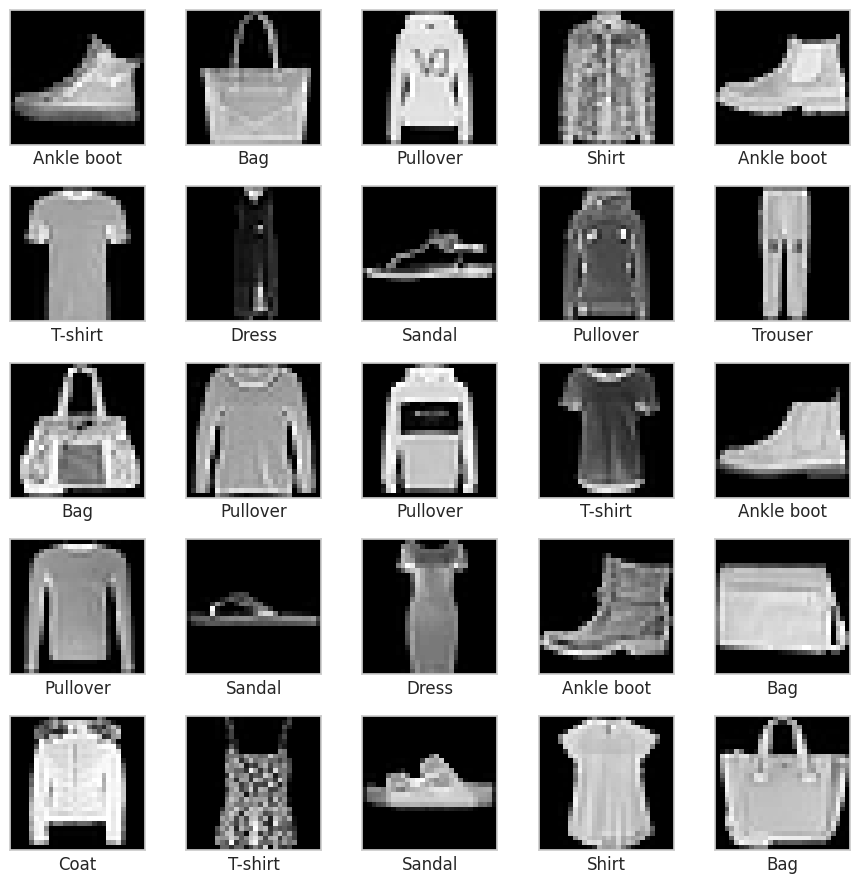

In [11]:
plt.figure(figsize=(9, 9))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(images[i][0], cmap="gray")     # [0] = the single grayscale channel
    plt.xlabel(class_names[labels[i]])
plt.tight_layout()
plt.show()

# 🧠 Part 3 — Build the CNN

We reuse the **`nn.Module` class** style from Lesson 1. The only new pieces are
`nn.Conv2d` and `nn.MaxPool2d`. Our tiny network is:

$$\text{image (1×28×28)} \rightarrow \text{Conv+ReLU+Pool} \rightarrow \text{Conv+ReLU+Pool} \rightarrow \text{Flatten} \rightarrow \text{Linear} \rightarrow \text{10 logits}$$


In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()                          # required first line
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # 1 -> 32 channels
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3)  # 32 -> 16 channels
        self.pool  = nn.MaxPool2d(2)                    # halves width & height
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 64)            # 400 -> 64
        self.fc2 = nn.Linear(64, n_classes)             # 64 -> 10 logits

    def forward(self, x):                            # describe the data flow
        x = self.pool(torch.relu(self.conv1(x)))     # conv -> relu -> pool
        x = self.pool(torch.relu(self.conv2(x)))     # conv -> relu -> pool
        x = self.flatten(x)                          # 2-D maps -> 1-D vector
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)                              # raw logits (no softmax here)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
# torchinfo prints the shape after every layer and the parameter count.
torchinfo.summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─MaxPool2d: 1-2                         [1, 32, 13, 13]           --
├─Conv2d: 1-3                            [1, 16, 11, 11]           4,624
├─MaxPool2d: 1-4                         [1, 16, 5, 5]             --
├─Flatten: 1-5                           [1, 400]                  --
├─Linear: 1-6                            [1, 64]                   25,664
├─Linear: 1-7                            [1, 10]                   650
Total params: 31,258
Trainable params: 31,258
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.80
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.13
Estimated Total Size (MB): 0.32

> 💡 The output layer has **10 neurons** — one *logit* per class. We do **not**
> add a softmax here: the loss function below (`CrossEntropyLoss`) applies it
> internally, which is numerically safer. This mirrors Lesson 1, where
> `BCEWithLogitsLoss` handled the sigmoid for us.

## Loss, optimizer, and the training loop ⭐

This is the **same loop** as Lesson 1, with one addition: we now iterate over
**mini-batches** from the `DataLoader` instead of feeding all data at once. Each
epoch still does the four familiar steps:

1. **Forward pass** — predictions from the model.
2. **Loss** — how wrong they are (`CrossEntropyLoss` for multi-class).
3. **Backward pass** — `loss.backward()` computes the gradients (autograd).
4. **Update** — `optimizer.step()` nudges the weights.

…and never forget **`optimizer.zero_grad()`** to reset gradients before each step.

In [14]:
def train_model(model, train_loader, val_loader, n_epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        # ---- training ----
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()                 # 0) reset gradients
            logits = model(xb)                    # 1) forward pass
            loss = criterion(logits, yb)          # 2) loss
            loss.backward()                       # 3) backward pass (autograd)
            optimizer.step()                      # 4) update the weights
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---- validation ----
        model.eval()
        vloss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                vloss += criterion(logits, yb).item() * xb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
        val_loss = vloss / len(val_loader.dataset)
        val_acc  = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"epoch {epoch+1:2d}/{n_epochs}  "
              f"train_loss={train_loss:.3f}  val_loss={val_loss:.3f}  val_acc={val_acc:.3f}")
    return history

In [15]:
history = train_model(model, train_loader, val_loader, n_epochs=5, lr=1e-3)

epoch  1/5  train_loss=0.662  val_loss=0.461  val_acc=0.833
epoch  2/5  train_loss=0.423  val_loss=0.400  val_acc=0.855
epoch  3/5  train_loss=0.369  val_loss=0.378  val_acc=0.863
epoch  4/5  train_loss=0.340  val_loss=0.344  val_acc=0.876
epoch  5/5  train_loss=0.322  val_loss=0.335  val_acc=0.881


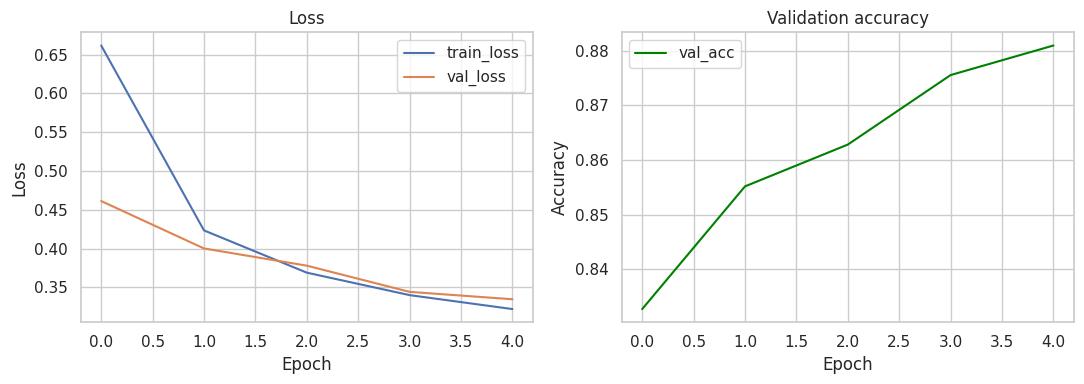

In [16]:
def show_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["train_loss"], label="train_loss")
    ax1.plot(history["val_loss"],   label="val_loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")
    ax2.plot(history["val_acc"], label="val_acc", color="green")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.set_title("Validation accuracy")
    plt.tight_layout(); plt.show()

show_history(history)

> 💡 Watch the two curves. The **training loss** should keep falling; if the
> **validation loss** starts rising while training loss falls, that gap is
> **overfitting**.

## 📊 Part 4 — Evaluate on the test set

The test set was never used for training — this is the honest score.

In [17]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(1).cpu().numpy()   # pick the class with the highest logit
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

acc = accuracy_score(all_true, all_preds)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.881


### Confusion matrix

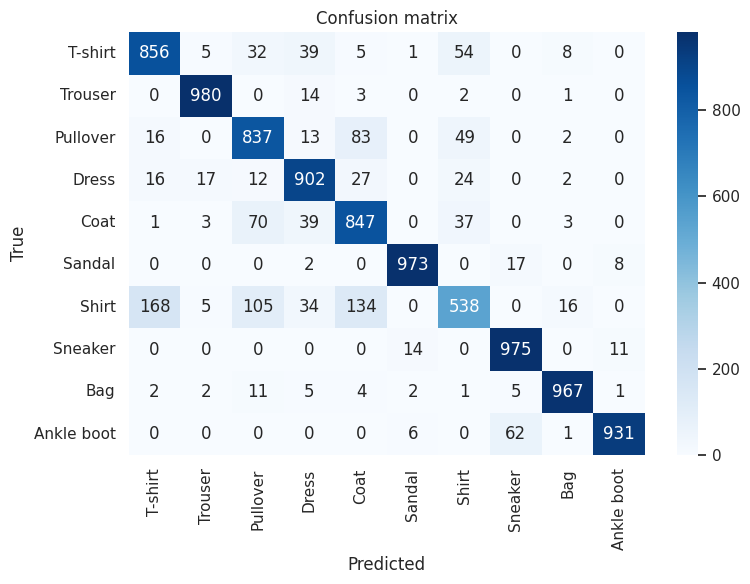

In [18]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix")
plt.tight_layout(); plt.show()

# 🔬 Part 5 — Look inside the network

Remember the hand-made filters from Part 1? The network learned its **own** filters
during training. Let's visualise what the convolutional layers produce for a single
image — these outputs are called **feature maps** (or *activations*).

input image: Ankle boot


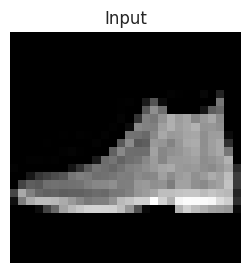

In [19]:
# Take one test image and push it through the layers one by one.
sample, sample_label = test_set[0]
sample = sample.unsqueeze(0).to(device)       # add the batch dimension -> (1, 1, 28, 28)

model.eval()
with torch.no_grad():
    act1 = torch.relu(model.conv1(sample))                    # after conv1 -> (1, 32, 26, 26)
    act2 = torch.relu(model.conv2(model.pool(act1)))          # after conv2 -> (1, 16, 11, 11)

print("input image:", class_names[sample_label])
plt.figure(figsize=(3, 3))
plt.imshow(sample.cpu()[0, 0], cmap="gray")
plt.title("Input"); plt.axis("off"); plt.show()

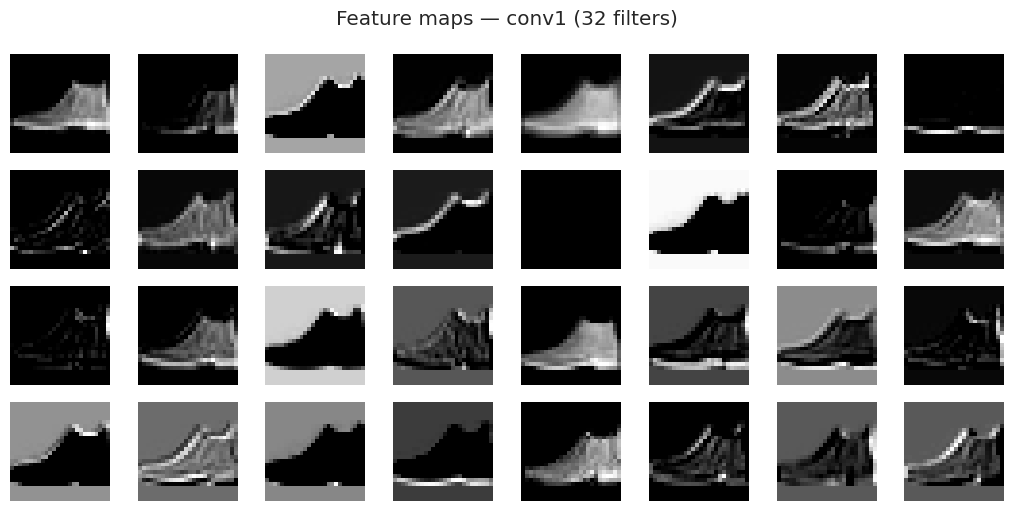

In [20]:
def show_feature_maps(activation, n_cols=8, title=""):
    activation = activation.cpu()[0]           # drop the batch dim -> (channels, H, W)
    n = activation.shape[0]
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.3))
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(activation[i], cmap="gray")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_feature_maps(act1, n_cols=8, title="Feature maps — conv1 (32 filters)")

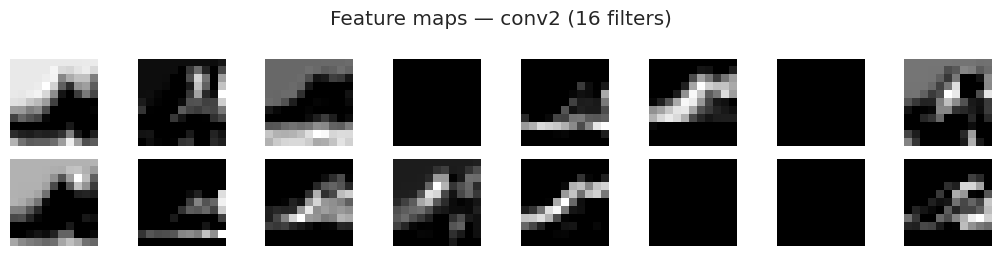

In [21]:
show_feature_maps(act2, n_cols=8, title="Feature maps — conv2 (16 filters)")

## 💡 What did we just see?

Each little square is the output of **one learned filter**. Some fire on **edges**,
some on **bright/dark regions**, some on **textures** — exactly the kinds of things
we built by hand in Part 1, except **the network discovered them by itself** from
the data. That is the whole magic of a CNN. ✨

# 🔎 How do we make a CNN better?

Two of the most useful additions:

### 📒 Batch Normalization
During training, the distribution of values inside the network keeps shifting as
the weights change (*internal covariate shift*). **BatchNorm** re-standardises each
layer's output to roughly zero mean and unit variance. Benefits:

- faster, more stable training (you can use higher learning rates),
- a mild **regularisation** effect (a little less overfitting).

In PyTorch: **`nn.BatchNorm2d(num_channels)`** after a conv layer.

### 📒 Dropout
**Dropout** randomly switches off a fraction of neurons during each training step,
forcing the network not to rely on any single one → less overfitting. In PyTorch:
**`nn.Dropout(0.2)`**. It is active only during `model.train()` and automatically
disabled during `model.eval()`.

### 📒 Mish activation
**Mish** is a smooth alternative to ReLU: $\text{mish}(x) = x \cdot \tanh(\ln(1+e^{x}))$.
Unlike ReLU it does not hard-cut negatives to zero, so gradients stay smooth and
neurons don't "die".

In [22]:
class BetterCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # padding=1 keeps 28x28
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(16)
        self.pool  = nn.MaxPool2d(2)
        self.act   = nn.Mish()                                    # built-in Mish
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(16 * 7 * 7, 64)                  # 28 ->14 ->7  => 16*7*7
        self.dropout = nn.Dropout(0.2)
        self.fc2     = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.pool(self.act(self.bn1(self.conv1(x))))          # 28 -> 14
        x = self.pool(self.act(self.bn2(self.conv2(x))))          # 14 -> 7
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

better_model = BetterCNN().to(device)
torchinfo.summary(better_model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
BetterCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─BatchNorm2d: 1-2                       [1, 32, 28, 28]           64
├─Mish: 1-3                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-4                         [1, 32, 14, 14]           --
├─Conv2d: 1-5                            [1, 16, 14, 14]           4,624
├─BatchNorm2d: 1-6                       [1, 16, 14, 14]           32
├─Mish: 1-7                              [1, 16, 14, 14]           --
├─MaxPool2d: 1-8                         [1, 16, 7, 7]             --
├─Flatten: 1-9                           [1, 784]                  --
├─Linear: 1-10                           [1, 64]                   50,240
├─Mish: 1-11                             [1, 64]                   --
├─Dropout: 1-12                          [1, 64]                   --
├─Linea

epoch  1/5  train_loss=0.433  val_loss=0.324  val_acc=0.886
epoch  2/5  train_loss=0.291  val_loss=0.282  val_acc=0.898
epoch  3/5  train_loss=0.260  val_loss=0.254  val_acc=0.905
epoch  4/5  train_loss=0.232  val_loss=0.251  val_acc=0.908
epoch  5/5  train_loss=0.214  val_loss=0.251  val_acc=0.912


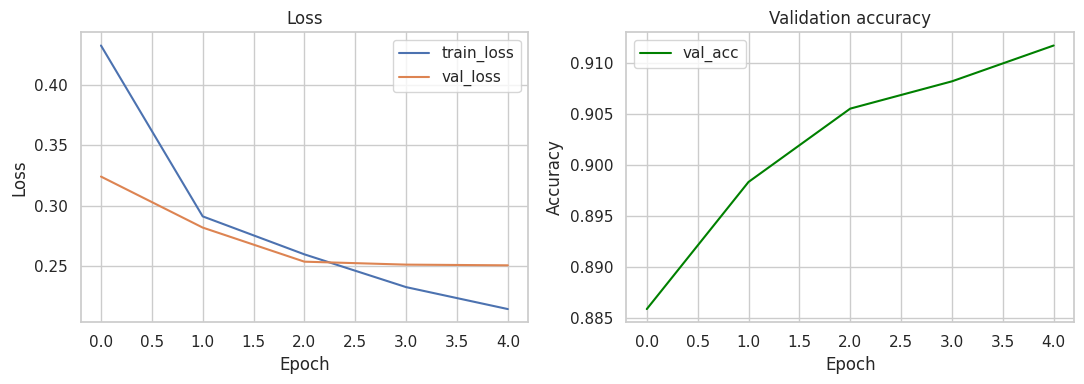

In [23]:
better_history = train_model(better_model, train_loader, val_loader, n_epochs=5, lr=1e-3)
show_history(better_history)

> 🔎 Compare the validation accuracy and the size of the train/val gap against
> the first model. Is the overfitting smaller?

In [28]:
better_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = better_model(xb)
        preds = logits.argmax(1).cpu().numpy()   # pick the class with the highest logit
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

acc = accuracy_score(all_true, all_preds)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.904


## 📒 Data augmentation

Deep learning is hungry for data, and collecting more is expensive. **Data
augmentation** is a cheap trick: create modified copies of existing images (flips,
small rotations, shifts) so the model sees more variety and generalises better.

In PyTorch, augmentation is just a **transform** applied while loading. It runs
**on the fly** — a different random version every epoch. Note we only augment the
**training** data, never validation/test.

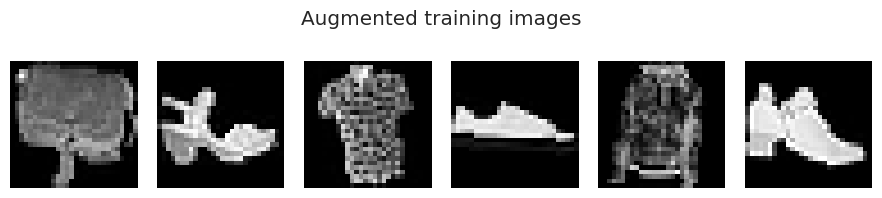

In [24]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # clothes are roughly left-right symmetric
    transforms.RandomRotation(10),              # small +/- 10 degree rotation
    transforms.ToTensor(),
])

# Rebuild ONLY the training dataset with augmentation (val/test stay clean)
aug_full_train = datasets.FashionMNIST(root="data", train=True, download=True,
                                       transform=train_transform)
aug_train_set, _ = random_split(aug_full_train, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))
aug_train_loader = DataLoader(aug_train_set, batch_size=BATCH_SIZE, shuffle=True)

# Show a few augmented samples
aug_images, aug_labels = next(iter(aug_train_loader))
plt.figure(figsize=(9, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(aug_images[i][0], cmap="gray"); plt.axis("off")
    plt.xlabel(class_names[aug_labels[i]])
plt.suptitle("Augmented training images")
plt.tight_layout(); plt.show()

epoch  1/5  train_loss=0.718  val_loss=0.524  val_acc=0.806
epoch  2/5  train_loss=0.475  val_loss=0.438  val_acc=0.842
epoch  3/5  train_loss=0.419  val_loss=0.394  val_acc=0.852
epoch  4/5  train_loss=0.388  val_loss=0.371  val_acc=0.865
epoch  5/5  train_loss=0.361  val_loss=0.351  val_acc=0.871


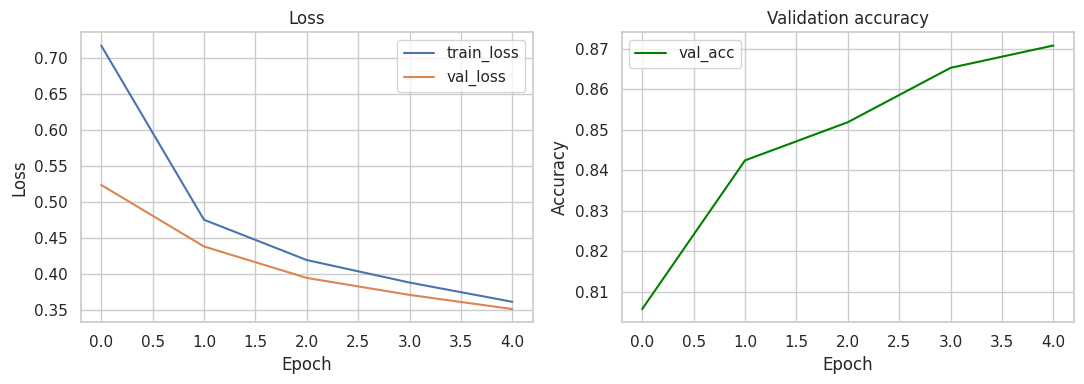

In [31]:
# Train a fresh model on the augmented data (reusing the same loop again).
aug_model = SimpleCNN().to(device)
aug_history = train_model(aug_model, aug_train_loader, val_loader, n_epochs=5, lr=1e-3)
show_history(aug_history)

In [32]:
aug_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = aug_model(xb)
        preds = logits.argmax(1).cpu().numpy()   # pick the class with the highest logit
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

acc = accuracy_score(all_true, all_preds)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.869


## 🚀 What if the dataset is too big to fit in memory?

So far the whole dataset lived in RAM. For large datasets you instead keep images
on **disk** in a folder-per-class structure and load them **lazily** in batches.

```
data_dir/
├── 0/  (all images of class 0)
├── 1/
└── ...
```

In PyTorch we use
**`torchvision.datasets.ImageFolder`** + a `DataLoader`. It infers the label from
the folder name and reads images from disk only when a batch is requested.

In [33]:
import os
from PIL import Image

# Save a small slice of FashionMNIST to disk as PNGs, one folder per class.
OUTPUT_DIR = "fashion_dir/train"
raw = datasets.FashionMNIST(root="data", train=True, download=True)  # PIL images, no transform

n_to_save = 2000                                   # keep it small & fast for the demo
for i in range(n_to_save):
    image, label = raw[i]                          # image is a PIL Image
    label_dir = os.path.join(OUTPUT_DIR, str(label))
    os.makedirs(label_dir, exist_ok=True)
    image.save(os.path.join(label_dir, f"{i:05d}.png"))

print("saved", n_to_save, "images to", OUTPUT_DIR)

saved 2000 images to fashion_dir/train


In [34]:
# Now stream them straight from the folder structure.
folder_dataset = datasets.ImageFolder(root=OUTPUT_DIR, transform=transforms.ToTensor())
folder_loader  = DataLoader(folder_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("classes found:", folder_dataset.classes)
xb, yb = next(iter(folder_loader))
print("batch shape:", xb.shape)                    # images are read from disk on demand

classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
batch shape: torch.Size([64, 3, 28, 28])


# Activities ✏️

Now it is your turn to change the code. Copy cells from above as a starting point.

## Activity 1 — Train longer & tune 🎚️

Retrain `SimpleCNN` and try to push the **test accuracy** higher:

- increase `n_epochs` (e.g. `10`–`20`),
- try a different learning rate (e.g. `5e-4`, `3e-3`),
- try a different `BATCH_SIZE` (lower = more stable but slower).

Which combination gives you the best validation accuracy?

## Activity 2 — Change the architecture 🏗️

Modify the network and see what happens. Try **at least two** of these:

- change the number of filters (e.g. `Conv2d(1, 64, 3)`),
- add a **third** convolutional block,
- change the kernel size to `5` (remember to recompute the `Linear` input size —
  or use `padding` to keep the maths simple).

## Activity 3 — Regularise it 🛡️

Start from `BetterCNN` (BatchNorm + Dropout + Mish). Train it for more epochs and
compare the train/validation gap with the plain `SimpleCNN`. Does the overfitting
shrink? Try changing the dropout rate (`0.1`, `0.3`, `0.5`).

## Activity 4 — Try harder datasets 🧪
1. **CIFAR-10 ≥ 80 %** — colour `32×32` images in 10 classes. **(1p)**
   - Load with `datasets.CIFAR10(...)`.
   - ⚠️ Input is now **3 channels**`
     and recompute the flattened size.
   - 💡 Train for more epochs (20–50). BatchNorm + Dropout + augmentation help a lot.
